<a href="https://colab.research.google.com/github/Vivek2428-netizen/ml-labwork/blob/main/exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [2]:
from google.colab import files

uploaded = files.upload()

Saving binary.dta to binary (1).dta


In [3]:
data = pd.read_stata("binary.dta")

In [4]:
data.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [5]:
print("Dataset Shape:", data.shape)

Dataset Shape: (400, 4)


In [6]:
print(data.isnull().sum())

admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [9]:
X = data[['gre','gpa','rank']]
y = data['admit']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 3)
(80, 3)
(320,)
(80,)


In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)

In [15]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print(conf_mat)

[[50  4]
 [23  3]]


In [16]:
accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

print("Accuracy Percentage :", round(accuracy*100,2),"%")

Accuracy Score : 0.6625
Accuracy Percentage : 66.25 %


In [17]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.68      0.93      0.79        54
         1.0       0.43      0.12      0.18        26

    accuracy                           0.66        80
   macro avg       0.56      0.52      0.48        80
weighted avg       0.60      0.66      0.59        80



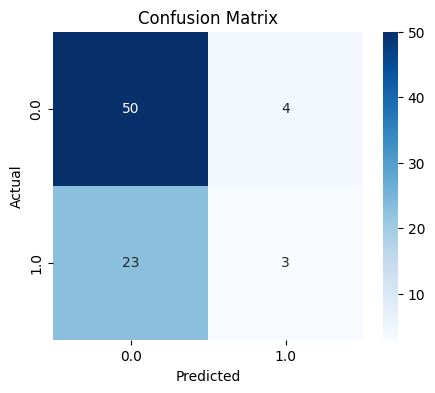

In [18]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

plt.figure(figsize=(5,4))

sns.heatmap(conf_mat,
            annot=True,
            cmap="Blues",
            fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [19]:
gre = 700
gpa = 3.8
rank = 2

prediction = model.predict([[gre,gpa,rank]])

if prediction[0]==1:
    print("Admitted")
else:
    print("Not Admitted")

Admitted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [20]:
import pandas as pd

new_student = pd.DataFrame({
    'gre': [700],
    'gpa': [3.8],
    'rank': [2]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Admitted")
else:
    print("Not Admitted")

Admitted
